## Packages

In [1]:
import numpy as np                                # scientific computing toolkit
import pandas as pd                               # data analysis toolkit
import scanpy as sc                               # scanpy is referred to with sc.***
import matplotlib.pyplot as plt                   # Matplotlib is referred to with plt.***
from scipy import stats                           # for linear regressions
import seaborn as sns                             # for easy heatmaps
import scirpy as ir                               # TCR analysis
#import scvelo as scv

sc.settings.verbosity = 3                         # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()                         # check if all needed versions are installed and up to date (old: print_Versions(), changed in new version of scanpy)
results_directory = './Analysis_output/'
results_file = results_directory + '/results_file/write/results.h5ad'             # the file that will store the analysis results

C:\Users\wwspa\miniconda3\envs\tcr_scripts\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sc.logging.print_header()  

C:\Users\wwspa\AppData\Local\Temp\ipykernel_7148\2120016042.py:1: RuntimeWarning: Failed to import dependencies for application/vnd.jupyter.widget-view+json representation. (ModuleNotFoundError: No module named 'ipywidgets')
  sc.logging.print_header()


Package,Version
numpy,2.1.1
pandas,2.3.0
scanpy,1.11.3
matplotlib,3.10.6
scipy,1.15.3
seaborn,0.13.2
scirpy,0.12.2
Component,Info
Python,"3.12.4 | packaged by Anaconda, Inc. | (main, Jun 18 2024, 15:03:56) [MSC v.1929 64 bit (AMD64)]"
OS,Windows-11-10.0.26200-SP0


In [3]:
pd.reset_option("^display")

## Directory variables

In [4]:
import glob
import os
from pathlib import Path

sample_directory = './gex_vdj/'
analysis_info = './analysis_info/'
adata_directory = './Annotated_files/'

In [5]:
plt.rcParams['figure.figsize']=(6,6) #rescale figures
### you can set a default figure directory here for saving output
sc.settings.figdir = "./analysis_output/figures_scanpy/"
## Figure directory for matplotlib figures/axes
save_figure_sc = "./analysis_output/figures_scanpy/"
#Use
#plt.savefig(save_figure + 'image.pdf')
save_figure_ir = "./analysis_output/figures_scirpy/"
#csv directory
read_csv = './analysis_output/saved_tables/'
save_csv = r'./analysis_output/saved_tables/'

## Load data

In [6]:
# define sample metadata. Usually read from a file.
samples = {
    "01_5_6_naive": {"experiment": "2_naive", "group": "naive_exp2"},
}

In [7]:
adatas = []

In [8]:
# Create a list of AnnData objects (one for each sample)
for sample, sample_meta in samples.items():
    adata = sc.read(f'{adata_directory}/{sample}_QC_proc.h5ad')
    adata.obs['mouse_concat'] = adata.obs.mouse.astype(str) + '_' + adata.obs.experiment.astype(str)
    adata.obs['mouse_concat'] = adata.obs['mouse_concat'].astype('category')
    adata.obs['isolated_specificity'] = 'naive'
    adatas.append(adata)
    

## Concatenation

In [9]:
adata = adatas[0].copy()

In [10]:
import gc
del adatas
gc.collect()

71

In [11]:
adata.obs['isolated_specificity'].unique()

array(['naive'], dtype=object)

In [12]:
adata.raw = adata.copy()

In [13]:
adata.layers['counts'] = adata.X.copy()

In [14]:
adata.obs.mouse.unique()

['m5_naive_1', 'm5_naive_2']
Categories (2, object): ['m5_naive_1', 'm5_naive_2']

In [15]:
adata.obs["mouse"] = (
    adata.obs["mouse"]
    .cat.rename_categories({
        "m5_naive_2": "m6_naive_2"
    })
)
adata.obs["mouse"] = (
    adata.obs["mouse"]
    .cat.rename_categories({
        "m5_naive_1": "m5_naive_2"
    })
)

No gene expression data acquired

In [16]:
adata

AnnData object with n_obs × n_vars = 64240 × 0
    obs: 'is_cell', 'high_confidence', 'multi_chain', 'extra_chains', 'IR_VJ_1_c_call', 'IR_VJ_2_c_call', 'IR_VDJ_1_c_call', 'IR_VDJ_2_c_call', 'IR_VJ_1_consensus_count', 'IR_VJ_2_consensus_count', 'IR_VDJ_1_consensus_count', 'IR_VDJ_2_consensus_count', 'IR_VJ_1_d_call', 'IR_VJ_2_d_call', 'IR_VDJ_1_d_call', 'IR_VDJ_2_d_call', 'IR_VJ_1_duplicate_count', 'IR_VJ_2_duplicate_count', 'IR_VDJ_1_duplicate_count', 'IR_VDJ_2_duplicate_count', 'IR_VJ_1_j_call', 'IR_VJ_2_j_call', 'IR_VDJ_1_j_call', 'IR_VDJ_2_j_call', 'IR_VJ_1_junction', 'IR_VJ_2_junction', 'IR_VDJ_1_junction', 'IR_VDJ_2_junction', 'IR_VJ_1_junction_aa', 'IR_VJ_2_junction_aa', 'IR_VDJ_1_junction_aa', 'IR_VDJ_2_junction_aa', 'IR_VJ_1_locus', 'IR_VJ_2_locus', 'IR_VDJ_1_locus', 'IR_VDJ_2_locus', 'IR_VJ_1_productive', 'IR_VJ_2_productive', 'IR_VDJ_1_productive', 'IR_VDJ_2_productive', 'IR_VJ_1_v_call', 'IR_VJ_2_v_call', 'IR_VDJ_1_v_call', 'IR_VDJ_2_v_call', 'has_ir', 'experiment', 'group'

### Integrate TCR expression

In [17]:
ir.tl.chain_qc(adata)

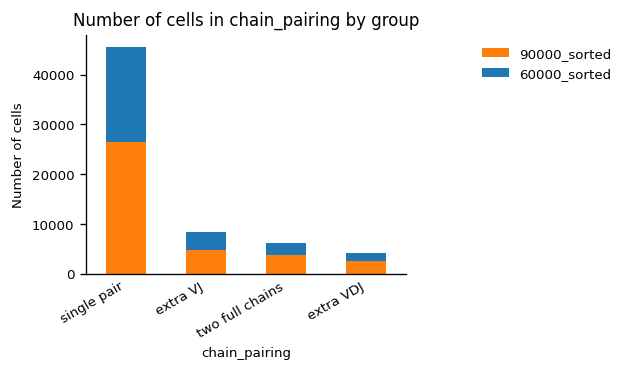

In [18]:
ax=ir.pl.group_abundance(adata, groupby='chain_pairing', target_col='group')
#ax.figure.savefig(save_figure_ir + 'chain_pairing_exp.eps')

Remove orphan and non-detected TCRs

In [19]:
before_tcr = adata.n_obs

In [20]:
adata = adata[adata.obs["has_ir"] != 'None',:]
adata = adata[~adata.obs["chain_pairing"].isin(["orphan VDJ", "orphan VJ"]), :]

In [21]:
after_tcr = adata.n_obs

In [22]:
print("Cells filtered out due to lack of full TCR expression: " + str(before_tcr-after_tcr))

Cells filtered out due to lack of full TCR expression: 0


## Clonotype integration

Annotate clono type size by donor

In [23]:
exp_list = adata.obs.experiment.unique().tolist()
mouse_list = adata.obs.mouse_concat.unique().tolist()

In [24]:
adata.obs['clonotype_size_mouse']=adata.obs.clone_id_aa_same_v_size

C:\Users\wwspa\AppData\Local\Temp\ipykernel_7148\3389217580.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['clonotype_size_mouse']=adata.obs.clone_id_aa_same_v_size


In [25]:
adata.obs['tra_id'] = adata.obs['IR_VJ_1_v_call'].astype(str) + '_' + adata.obs['IR_VJ_1_j_call'].astype(str) + '_' + adata.obs['IR_VJ_1_junction_aa'].astype(str)
adata.obs['trb_id'] = adata.obs['IR_VDJ_1_v_call'].astype(str) + '_' + adata.obs['IR_VDJ_1_j_call'].astype(str) + '_' + adata.obs['IR_VDJ_1_junction_aa'].astype(str)
adata.obs['tcr_id'] = adata.obs['tra_id'] + '__' + adata.obs['trb_id']



In [26]:
adata.obs["TCR_expansion"] = (
    adata.obs
    .groupby(["mouse", "tcr_id"], sort=False, observed=True)["tcr_id"]
    .transform("size")
)
adata.obs['clonotype_size_mouse']=adata.obs["TCR_expansion"].copy()

In [27]:
adata.obs["isolated_specificity"] = 'naive'
adata.obs["sequencing_specificity"] = "naive"

In [28]:
adata.obs['cell_id'] = adata.obs.index.copy()

In [29]:
adata.obs['NAME'] = adata.obs.index.copy()
adata.obs['donor_id'] = adata.obs['mouse_concat']
adata.obs['biosample_id'] = adata.obs['experiment']
adata.obs['species'] = 'NCBITaxon_10090'
adata.obs['species__strain'] = 'C57BL/6'
adata.obs['species__ontology_label'] = 'Mus_musculus'
adata.obs['disease'] = 'PATO_0000461'
adata.obs['disease__strain'] = 'uninfected'
adata.obs['disease__ontology_label'] = 'normal'
adata.obs['disease__epitope'] = 'none'
adata.obs['disease__antigen'] = 'none'
adata.obs['organ'] = 'UBERON_0002106'
adata.obs['organ__ontology_label'] = 'spleen'
adata.obs['library_preparation_protocol'] = 'EFO_0009900'
adata.obs['library_preparation_protocol__ontology_label'] = "10x 5' v2"
adata.obs['cell_type'] = "CL_0000625"
adata.obs['cell_type__ontology_label'] = "CD8-positive, alpha-beta T cell"
adata.obs['sex'] = 'female'


In [30]:
adata_file = 'processed_adata_naive_2.h5ad'
adata.write(adata_directory+adata_file)

In [31]:
df_obs = pd.DataFrame(adata.obs)

for col in df_obs.columns:
    if isinstance(df_obs[col].dtype, pd.CategoricalDtype):
        categories = df_obs[col].cat.categories
        
        if all(isinstance(x, str) for x in categories):
            df_obs[col] = df_obs[col].astype("string")
			
from preprocess_tcr_2 import preprocess_tcr_vj_vdj

df = preprocess_tcr_vj_vdj(df_obs)

In [32]:
tcr_file_cols =  ['multi_chain', 'extra_chains', 'IR_VJ_1_c_call', 'IR_VJ_2_c_call',
       'IR_VDJ_1_c_call', 'IR_VDJ_2_c_call', 'IR_VJ_1_d_call',
       'IR_VJ_2_d_call', 'IR_VDJ_1_d_call', 'IR_VDJ_2_d_call',
       'IR_VJ_1_j_call', 'IR_VJ_2_j_call', 'IR_VDJ_1_j_call',
       'IR_VDJ_2_j_call', 'IR_VJ_1_junction', 'IR_VJ_2_junction',
       'IR_VDJ_1_junction', 'IR_VDJ_2_junction', 'IR_VJ_1_junction_aa',
       'IR_VJ_2_junction_aa', 'IR_VDJ_1_junction_aa', 'IR_VDJ_2_junction_aa',
       'IR_VJ_1_locus', 'IR_VJ_2_locus', 'IR_VDJ_1_locus', 'IR_VDJ_2_locus',
       'IR_VJ_1_productive', 'IR_VJ_2_productive', 'IR_VDJ_1_productive',
       'IR_VDJ_2_productive', 'IR_VJ_1_v_call', 'IR_VJ_2_v_call',
       'IR_VDJ_1_v_call', 'IR_VDJ_2_v_call', 'has_ir', 'cell_id', 'mouse',
       'experiment', 'isolated_specificity', 'receptor_type',
       'receptor_subtype', 'chain_pairing', 'assigned_TRA',
       'assigned_TRB', 'TRB', 'TRA', 'TCR', 'TCR_expansion',
       'TCR_expansion_full_data', 'TRA2', 'TRB2', 'dual_tcr', 'n_cells_mouse',
       'sequencing_specificity', 'NAME', 'donor_id', 'biosample_id', 'species',
       'species__strain', 'species__ontology_label', 'disease',
       'disease__strain', 'disease__ontology_label', 'disease__epitope',
       'disease__antigen', 'organ',
       'organ__ontology_label', 'library_preparation_protocol',
       'library_preparation_protocol__ontology_label', 'cell_type',
       'cell_type__ontology_label', 'sex']

meta_data_cols = ['NAME', 'donor_id', 'biosample_id', 'species',
       'species__strain', 'species__ontology_label', 'disease',
       'disease__strain', 'disease__ontology_label', 'disease__epitope',
       'disease__antigen', 'organ',
       'organ__ontology_label', 'library_preparation_protocol',
       'library_preparation_protocol__ontology_label', 'cell_type',
       'cell_type__ontology_label', 'sex']

In [33]:
obs_filename = 'obs_df_naive_2'
tcr_filename = 'naive_2_tcr_data'
meta_filename = 'naive_2_metadata'

tcr_data = df[tcr_file_cols]
tcr_data.to_csv("./" + obs_filename + ".csv", index=False)
tcr_data.to_csv(
    "./" + tcr_filename + ".tsv.gz",
    sep="\t",
    index=False,
    compression="gzip"
)
metadata = df[meta_data_cols]
metadata.to_csv(
    "./" + meta_filename + ".tsv.gz",
    sep="\t",
    index=False,
    compression="gzip"
)

In [34]:
adata

AnnData object with n_obs × n_vars = 64240 × 0
    obs: 'is_cell', 'high_confidence', 'multi_chain', 'extra_chains', 'IR_VJ_1_c_call', 'IR_VJ_2_c_call', 'IR_VDJ_1_c_call', 'IR_VDJ_2_c_call', 'IR_VJ_1_consensus_count', 'IR_VJ_2_consensus_count', 'IR_VDJ_1_consensus_count', 'IR_VDJ_2_consensus_count', 'IR_VJ_1_d_call', 'IR_VJ_2_d_call', 'IR_VDJ_1_d_call', 'IR_VDJ_2_d_call', 'IR_VJ_1_duplicate_count', 'IR_VJ_2_duplicate_count', 'IR_VDJ_1_duplicate_count', 'IR_VDJ_2_duplicate_count', 'IR_VJ_1_j_call', 'IR_VJ_2_j_call', 'IR_VDJ_1_j_call', 'IR_VDJ_2_j_call', 'IR_VJ_1_junction', 'IR_VJ_2_junction', 'IR_VDJ_1_junction', 'IR_VDJ_2_junction', 'IR_VJ_1_junction_aa', 'IR_VJ_2_junction_aa', 'IR_VDJ_1_junction_aa', 'IR_VDJ_2_junction_aa', 'IR_VJ_1_locus', 'IR_VJ_2_locus', 'IR_VDJ_1_locus', 'IR_VDJ_2_locus', 'IR_VJ_1_productive', 'IR_VJ_2_productive', 'IR_VDJ_1_productive', 'IR_VDJ_2_productive', 'IR_VJ_1_v_call', 'IR_VJ_2_v_call', 'IR_VDJ_1_v_call', 'IR_VDJ_2_v_call', 'has_ir', 'experiment', 'group'